# Learning in Games: Fictitious Play, Regret Matching and Q-Learning

*A worked walkthrough of how simple adaptive rules behave in repeated normal-form games. The main thread follows Shoham & Leyton-Brown (2009, Ch. 7) and Fudenberg & Levine (1998); each section also points to the original papers. Full references are at the end.*

The first notebook computed equilibria from the outside, with full knowledge of the payoff matrices. Here we change the question. Suppose two players meet again and again, each following some simple rule for choosing what to do next based on what has happened so far. Do they end up at a Nash equilibrium? If so, in what sense, and how fast? If not, what do they do instead?

We implement three rules that differ in how much they assume:

- **Fictitious play** knows its own payoffs and watches the opponent's actions. It best-responds to the opponent's past behaviour.
- **Regret matching** knows its own payoffs and asks, after every round, how much better each alternative would have done.
- **Q-learning** knows nothing about the game. It only sees the reward it received and learns by trial and error.

The answers turn out to depend on the game, and on what exactly we mean by "converge". That second point is the main lesson of this notebook.

| § | Topic | Function | Shoham & Leyton-Brown |
|---|---|---|---|
| 1 | Tools from notebook 01 | `best_response`, `is_nash`, ... | Ch. 3–4 |
| 2 | Measuring distance to equilibrium | `nash_conv` | §3.4.7 |
| 3 | Fictitious play | `fictitious_play` | §7.2 |
| 4 | Regret matching | `regret_matching` | §7.5 |
| 5 | Q-learning | `q_learning` | §7.4 |
| 6 | Side by side | `run_all` | |
| 7 | Discussion | | §7.7.1 |

Some sections end with a **Going further** note: a paper or an extension worth reading or implementing next.

In [1]:
# %pip install numpy scipy pandas matplotlib
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TOL = 1e-8
np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 1 · Tools from notebook 01

The cell below repeats the functions we need from `01_computing_equilibria.ipynb`, with shortened docstrings, so that this notebook runs on its own. Once the repository is set up they will be imported from `engine/solvers.py` instead.

We also add one game. **Shapley's game** (Shapley, 1964) is a 3×3 variant of rock-paper-scissors that is *not* zero-sum. It has a unique equilibrium, in which both players mix uniformly, and it was introduced precisely as an example where fictitious play fails to find it.

In [2]:
GAMES = {
    "prisoners_dilemma":   (np.array([[3, 0], [5, 1]]),
                            np.array([[3, 5], [0, 1]])),
    "matching_pennies":    (np.array([[1, -1], [-1, 1]]),
                            np.array([[-1, 1], [1, -1]])),
    "rock_paper_scissors": (np.array([[0, -1, 1], [1, 0, -1], [-1, 1, 0]]),
                            np.array([[0, 1, -1], [-1, 0, 1], [1, -1, 0]])),
    "battle_of_the_sexes": (np.array([[2, 0], [0, 1]]),
                            np.array([[1, 0], [0, 2]])),
    "coordination":        (np.array([[2, 0], [0, 1]]),
                            np.array([[2, 0], [0, 1]])),
    "dominance_solvable":  (np.array([[4, 5, 6], [2, 8, 3], [3, 9, 2]]),
                            np.array([[3, 1, 2], [1, 4, 6], [0, 6, 8]])),
    "shapley":             (np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]),
                            np.array([[0, 1, 0], [0, 0, 1], [1, 0, 0]])),
}


def pure(k, n):
    '''Pure strategy "always play k" (counted from 0) as a probability vector of length n.'''
    v = np.zeros(n)
    v[k] = 1.0
    return v


def expected_payoff(M, x, y):
    '''Expected payoff x^T M y.'''
    return float(x @ M @ y)


def best_response(M, y):
    '''All pure best responses (rows of M) to the opponent's mix y, ties included.'''
    vals = M @ y
    return np.flatnonzero(vals >= vals.max() - TOL)


def is_nash(A, B, x, y):
    '''True if (x, y) is a Nash equilibrium of (A, B).'''
    return bool((A @ y).max() <= x @ A @ y + TOL and (x @ B).max() <= x @ B @ y + TOL)


def solve_indifference(M, rows, cols):
    '''Opponent mix on cols that makes this player indifferent over rows (None if singular).'''
    k = len(rows)
    S = np.zeros((k + 1, k + 1)); rhs = np.zeros(k + 1)
    S[:k, :k] = M[np.ix_(rows, cols)]; S[:k, k] = -1; S[k, :k] = 1; rhs[k] = 1
    try:
        sol = np.linalg.solve(S, rhs)
    except np.linalg.LinAlgError:
        return None
    y = np.zeros(M.shape[1]); y[list(cols)] = sol[:k]
    return y


def support_enumeration(A, B):
    '''All Nash equilibria of a nondegenerate bimatrix game.'''
    m, n = A.shape
    eqs = []
    for k in range(1, min(m, n) + 1):
        for rows in itertools.combinations(range(m), k):
            for cols in itertools.combinations(range(n), k):
                y = solve_indifference(A, rows, cols)
                x = solve_indifference(B.T, cols, rows)
                if x is None or y is None or (x < -TOL).any() or (y < -TOL).any():
                    continue
                x, y = np.clip(x, 0, None), np.clip(y, 0, None)
                if is_nash(A, B, x, y):
                    eqs.append((x, y))
    return eqs

In [3]:
A, B = GAMES["shapley"]
for x, y in support_enumeration(A, B):
    print("Shapley's game equilibrium:  x =", x, " y =", y)

Shapley's game equilibrium:  x = [0.333 0.333 0.333]  y = [0.333 0.333 0.333]


## 2 · Measuring distance to equilibrium

`is_nash` gives a yes-or-no answer. To watch a learning process approach an equilibrium, we need a number that shrinks as it gets closer. The natural choice asks each player how much she could gain by switching to a best response, and adds the two gains:

$$\text{NashConv}(x, y) \;=\; \Big(\max_i\, (A y)_i - x^\top A y\Big) \;+\; \Big(\max_j\, (x^\top B)_j - x^\top B y\Big).$$

Both terms are non-negative. The sum is zero exactly at a Nash equilibrium, and a profile with NashConv at most $\varepsilon$ is an $\varepsilon$-Nash equilibrium (§3.4.7). The name comes from Lanctot et al. (2017); in two-player zero-sum games the same quantity, halved, is usually called **exploitability**.

This measure will be used on two different objects, and keeping them apart matters:

- the **current strategy** a learner uses at round $t$ (the *last iterate*);
- the **time average** of what it has played up to round $t$.

Many classical results are about the second one only.

In [4]:
def nash_conv(A, B, x, y):
    '''Total gain available to the two players from unilateral deviation.

    Parameters
    ----------
    A, B : np.ndarray, shape (m, n)
        Payoff matrices of the row and the column player.
    x : np.ndarray, shape (m,)
        Row player's mixed strategy.
    y : np.ndarray, shape (n,)
        Column player's mixed strategy.

    Returns
    -------
    float
        Zero exactly at a Nash equilibrium, positive otherwise.
    '''
    row_gain = (A @ y).max() - x @ A @ y
    col_gain = (x @ B).max() - x @ B @ y
    return float(row_gain + col_gain)

In [5]:
A, B = GAMES["matching_pennies"]
for p in [0.5, 0.6, 0.8, 1.0]:
    x = np.array([p, 1 - p])
    y = np.array([0.5, 0.5])
    print(f"row plays Heads with p = {p:.1f}:  NashConv = {nash_conv(A, B, x, y):.2f}")

row plays Heads with p = 0.5:  NashConv = 0.00
row plays Heads with p = 0.6:  NashConv = 0.20
row plays Heads with p = 0.8:  NashConv = 0.60
row plays Heads with p = 1.0:  NashConv = 1.00


Only the column player gains when the row player leans towards Heads, and her gain grows linearly with the bias.

In [6]:
# sanity checks
for name, (A, B) in GAMES.items():
    for x, y in support_enumeration(A, B):
        assert abs(nash_conv(A, B, x, y)) < 1e-7, name
A, B = GAMES["prisoners_dilemma"]
assert nash_conv(A, B, pure(0, 2), pure(0, 2)) == 4       # each player gains 2 by defecting
print("✓ nash_conv")

✓ nash_conv


### Plotting helpers

Two small functions for pictures. For 2×2 games a mixed profile is just a pair of numbers, the probability each player puts on her first action, so a learning path is a curve in the unit square. For three actions a mixed strategy lives in a triangle (the probability simplex): each corner is a pure strategy and the centre is the uniform mix.

In [7]:
def plot_square(paths, eqs=(), labels=("row: P(action 0)", "col: P(action 0)"), title=""):
    '''Plot learning paths of a 2x2 game in the unit square.

    Parameters
    ----------
    paths : dict of name -> (X, Y)
        X, Y are arrays of shape (T, 2) with the strategies of the two players over time.
    eqs : list of (x, y)
        Equilibria to mark with a star.
    '''
    fig, ax = plt.subplots(figsize=(4.2, 4.2))
    for name, (X, Y) in paths.items():
        ax.plot(X[:, 0], Y[:, 0], lw=1, label=name)
        ax.plot(X[0, 0], Y[0, 0], "o", ms=4, color=ax.lines[-1].get_color())
    for x, y in eqs:
        ax.plot(x[0], y[0], "*", ms=14, color="black")
    ax.set(xlim=(-0.03, 1.03), ylim=(-0.03, 1.03), xlabel=labels[0], ylabel=labels[1], title=title)
    ax.set_aspect("equal")
    if len(paths) > 1:
        ax.legend(fontsize=8)
    plt.show()


def _to_triangle(P):
    # barycentric (p0, p1, p2) -> 2D point inside an equilateral triangle
    P = np.atleast_2d(P)
    return P[:, 1] + P[:, 2] / 2, P[:, 2] * np.sqrt(3) / 2


def plot_simplex(paths, eq=None, corners=("0", "1", "2"), title=""):
    '''Plot 3-action strategy paths in the probability simplex.

    Parameters
    ----------
    paths : dict of name -> X
        X is an array of shape (T, 3).
    eq : np.ndarray of shape (3,), optional
        An equilibrium strategy to mark with a star.
    corners : labels of the three pure strategies.
    '''
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3) / 2, 0], color="grey", lw=0.8)
    for (cx, cy), lab in zip([(0, 0), (1, 0), (0.5, np.sqrt(3) / 2)], corners):
        ax.annotate(lab, (cx, cy), textcoords="offset points",
                    xytext=(0, -12 if cy == 0 else 6), ha="center", fontsize=9)
    for name, X in paths.items():
        u, v = _to_triangle(X)
        ax.plot(u, v, lw=0.8, label=name)
    if eq is not None:
        u, v = _to_triangle(eq)
        ax.plot(u, v, "*", ms=14, color="black")
    ax.set_title(title)
    ax.axis("off"); ax.set_aspect("equal")
    if len(paths) > 1:
        ax.legend(fontsize=8, loc="upper right")
    plt.show()


def plot_nash_conv(curves, title="", logx=True):
    '''Plot NashConv over time for several named curves (dict of name -> array).'''
    fig, ax = plt.subplots(figsize=(6, 3.2))
    for name, c in curves.items():
        ax.plot(np.arange(1, len(c) + 1), c, lw=1, label=name)
    if logx:
        ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set(xlabel="round t", ylabel="NashConv", title=title)
    ax.legend(fontsize=8)
    plt.show()


def nash_conv_path(A, B, X, Y):
    '''NashConv at every round of a strategy history.'''
    return np.array([nash_conv(A, B, x, y) for x, y in zip(X, Y)])

## 3 · Fictitious play

Fictitious play (Brown, 1951) is the oldest learning rule in game theory and still the cleanest place to start. Each player behaves as if the opponent were drawing actions from a fixed distribution, estimates that distribution by the empirical frequencies so far, and plays a best response to the estimate:

$$\bar y_t \;=\; \frac{1}{t}\sum_{s=1}^{t} e_{j_s}, \qquad i_{t+1} \in \arg\max_i\, (A \bar y_t)_i ,$$

and symmetrically for the column player. Here $e_{j}$ is `pure(j, n)`. The belief is wrong in an important way: the opponent is also learning, so her play is not stationary. Whether this mistake washes out is the whole question.

A few implementation choices need to be made explicit.

- **Initial beliefs.** Before any play there are no frequencies. We start each player with one fictitious observation of the opponent's first action. Other choices change the path, not the long-run behaviour.
- **Ties.** When several actions are best responses we take the one with the lowest index. Brown's rule allows any tie-breaking; deterministic tie-breaking makes runs reproducible.
- **Timing.** Both players update simultaneously, as in Brown's original "simultaneous" version. The book (§7.2) also discusses the alternating version.

The function records, for every round, the action each player chose (the current strategy, always pure) and the empirical frequencies after that round (the time average).

In [8]:
def fictitious_play(A, B, T, init=(0, 0)):
    '''Simultaneous fictitious play on the bimatrix game (A, B).

    Parameters
    ----------
    A, B : np.ndarray, shape (m, n)
        Payoff matrices of the row and the column player.
    T : int
        Number of rounds.
    init : (int, int)
        One fictitious prior observation of each player's action, used as the
        opponent's initial belief.

    Returns
    -------
    dict with arrays of length T:
        "x", "y"          : current (pure) strategies played in each round, shapes (T, m), (T, n)
        "x_avg", "y_avg"  : empirical frequencies after each round, shapes (T, m), (T, n)
    '''
    m, n = A.shape
    count_x = pure(init[0], m)
    count_y = pure(init[1], n)
    hist = {k: [] for k in ["x", "y", "x_avg", "y_avg"]}
    for t in range(T):
        belief_about_y = count_y / count_y.sum()
        belief_about_x = count_x / count_x.sum()
        i = best_response(A, belief_about_y)[0]      # lowest-index tie-breaking
        j = best_response(B.T, belief_about_x)[0]
        count_x[i] += 1
        count_y[j] += 1
        hist["x"].append(pure(i, m));  hist["x_avg"].append(count_x / count_x.sum())
        hist["y"].append(pure(j, n));  hist["y_avg"].append(count_y / count_y.sum())
    return {k: np.array(v) for k, v in hist.items()}

### Matching pennies: the averages converge, the play does not

Let us look at the first rounds of play and then at the long run.

In [9]:
A, B = GAMES["matching_pennies"]
h = fictitious_play(A, B, T=20_000)

names = ["H", "T"]
seq = [names[int(x[1])] + names[int(y[1])] for x, y in zip(h["x"][:24], h["y"][:24])]
print("first 24 rounds (row, col):", " ".join(seq))
print("empirical frequencies after 20,000 rounds:", h["x_avg"][-1], h["y_avg"][-1])

first 24 rounds (row, col): HT HT TT TT TT TH TH TH TH HH HH HH HH HH HT HT HT HT HT HT TT TT TT TT
empirical frequencies after 20,000 rounds: [0.497 0.503] [0.498 0.502]


The actual play is a deterministic cycle with runs that get longer and longer: the row player keeps playing Heads until the column player's belief tips, the column player switches, the row player's belief tips, and so on. Each player is **always** playing a pure strategy and is therefore always exploitable. Yet the *frequencies* approach the fair coin, the unique equilibrium.

Robinson (1951) proved that this is not a coincidence: in every two-player zero-sum game, the empirical frequencies of fictitious play converge to the set of equilibria. The picture shows why the word "frequencies" is doing so much work in that sentence.

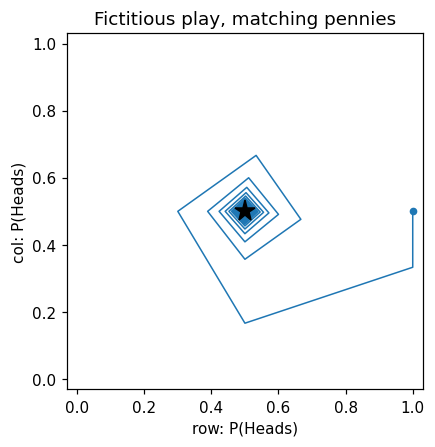

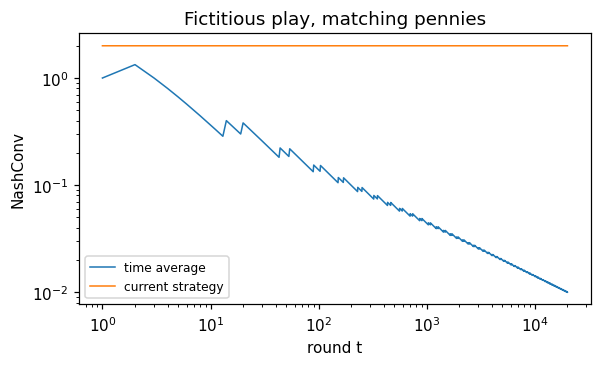

In [10]:
eqs = support_enumeration(A, B)
plot_square({"empirical frequencies": (h["x_avg"], h["y_avg"])}, eqs=eqs,
            labels=("row: P(Heads)", "col: P(Heads)"),
            title="Fictitious play, matching pennies")
plot_nash_conv({"time average": nash_conv_path(A, B, h["x_avg"], h["y_avg"]),
                "current strategy": nash_conv_path(A, B, h["x"], h["y"])},
               title="Fictitious play, matching pennies")

The spiral in the square closes in on the equilibrium, while NashConv of the current strategy never leaves 2, the largest value possible in this game. On the log–log scale the average's NashConv decreases roughly like a straight line, i.e. polynomially in $t$. How fast fictitious play converges in zero-sum games was a long-open question: Karlin (1959) conjectured a rate of $O(t^{-1/2})$, and Daskalakis & Pan (2014) showed that with adversarial tie-breaking it can be much slower.

### Shapley's game: even the averages fail

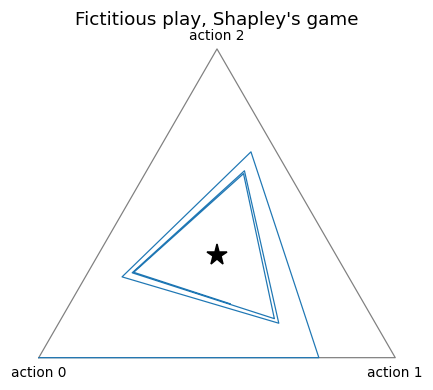

NashConv of the averages at t = 1,000 / 10,000 / 20,000: [0.294, 0.288, 0.285]


In [11]:
A, B = GAMES["shapley"]
h = fictitious_play(A, B, T=20_000)
eq = support_enumeration(A, B)[0][0]

plot_simplex({"row player, empirical frequencies": h["x_avg"]}, eq=eq,
             corners=("action 0", "action 1", "action 2"),
             title="Fictitious play, Shapley's game")
print("NashConv of the averages at t = 1,000 / 10,000 / 20,000:",
      [round(nash_conv(A, B, h["x_avg"][t - 1], h["y_avg"][t - 1]), 3) for t in [1_000, 10_000, 20_000]])

Instead of spiralling inwards, the frequencies circle the equilibrium along a triangle-shaped orbit, and NashConv does not go to zero. Each "run" of the cycle lasts longer than the last one, which is exactly why the averages do not settle: late, long runs keep dragging them around. Shapley (1964) proved this happens for his game from essentially every starting point.

So fictitious play converges in some classes of games and not in others. The known positive cases include zero-sum games (Robinson, 1951), generic 2×2 games (Miyasawa, 1961) and games with identical interests (Monderer & Shapley, 1996). Shapley's game shows that the list cannot be extended to all games.

In [12]:
# sanity checks
A, B = GAMES["matching_pennies"]
h = fictitious_play(A, B, T=20_000)
assert nash_conv(A, B, h["x_avg"][-1], h["y_avg"][-1]) < 0.02          # averages converge
assert min(nash_conv_path(A, B, h["x"][-100:], h["y"][-100:])) > 1.0    # play does not

A, B = GAMES["shapley"]
h = fictitious_play(A, B, T=20_000)
assert nash_conv(A, B, h["x_avg"][-1], h["y_avg"][-1]) > 0.1           # no convergence

A, B = GAMES["dominance_solvable"]
h = fictitious_play(A, B, T=2_000)
assert np.allclose(h["x"][-1], pure(0, 3)) and np.allclose(h["y"][-1], pure(0, 3))
print("✓ fictitious_play")

✓ fictitious_play


> **Going further.** Replace the hard best response with a softmax over expected payoffs. This is *smooth* fictitious play (Fudenberg & Kreps, 1993; Fudenberg & Levine, 1998, Ch. 4). The current strategy is then mixed, and in zero-sum games it can converge itself, not just on average. Run it on Shapley's game and see what changes.

## 4 · Regret matching

Fictitious play looks forward: "given what I think you will do, what is best for me?" Regret matching looks backward: "given what actually happened, how much better would each of my actions have done?"

For the row player, the cumulative **regret** for not having played action $i$ in the first $t$ rounds is

$$R_t(i) \;=\; \sum_{s=1}^{t} \big(A_{i\,j_s} - A_{i_s j_s}\big),$$

the total extra payoff she would have collected by playing $i$ every time, holding the opponent's actual actions fixed. Regret matching then plays each action with probability proportional to its positive regret:

$$x_{t+1}(i) \;=\; \frac{[R_t(i)]^+}{\sum_k [R_t(k)]^+},$$

and uniformly at random if no regret is positive. Actions that would have done well get played more; actions that would not, are dropped.

Two properties are worth knowing before looking at the code.

- **No regret.** The average regret $\max_i R_t(i)/t$ goes to zero whatever the opponent does, even an adversarial one. This property is called Hannan consistency (Hannan, 1957). It is a guarantee about the player alone, not about the game.
- **What it implies for the game.** If *both* players have vanishing average regret, their joint play converges to the set of **coarse correlated equilibria**. In two-player zero-sum games this is enough to make the average strategies approach the minimax (Nash) strategies. In general games it is not.

The version here uses *unconditional* regrets as above; it is the rule behind modern poker solvers via counterfactual regret minimisation (Zinkevich et al., 2007). Hart & Mas-Colell (2000) introduced the rule with *conditional* regrets ("how much better would $k$ have been on the rounds when I played $j$?"), which yields convergence to the smaller set of correlated equilibria. The actions are sampled, so runs depend on the random seed.

In [13]:
def _regret_matching_strategy(R):
    '''Probabilities proportional to positive regret; uniform if none is positive.'''
    pos = np.maximum(R, 0)
    total = pos.sum()
    return pos / total if total > 0 else np.ones(len(R)) / len(R)


def regret_matching(A, B, T, seed=0):
    '''Unconditional regret matching for both players of (A, B).

    Parameters
    ----------
    A, B : np.ndarray, shape (m, n)
        Payoff matrices of the row and the column player.
    T : int
        Number of rounds.
    seed : int
        Seed of the random generator used to sample actions.

    Returns
    -------
    dict with arrays of length T:
        "x", "y"          : mixed strategies used in each round
        "x_avg", "y_avg"  : empirical frequencies of the sampled actions
        "avg_regret"      : largest average regret of the two players after each round
    '''
    rng = np.random.default_rng(seed)
    m, n = A.shape
    R_x, R_y = np.zeros(m), np.zeros(n)
    count_x, count_y = np.zeros(m), np.zeros(n)
    hist = {k: [] for k in ["x", "y", "x_avg", "y_avg", "avg_regret"]}
    for t in range(1, T + 1):
        x = _regret_matching_strategy(R_x)
        y = _regret_matching_strategy(R_y)
        i = rng.choice(m, p=x)
        j = rng.choice(n, p=y)
        R_x += A[:, j] - A[i, j]          # what each row would have earned, minus what i earned
        R_y += B[i, :] - B[i, j]
        count_x[i] += 1
        count_y[j] += 1
        hist["x"].append(x);  hist["x_avg"].append(count_x / t)
        hist["y"].append(y);  hist["y_avg"].append(count_y / t)
        hist["avg_regret"].append(max(R_x.max(), R_y.max(), 0) / t)
    return {k: np.array(v) for k, v in hist.items()}

### Rock-paper-scissors: no regret means equilibrium on average

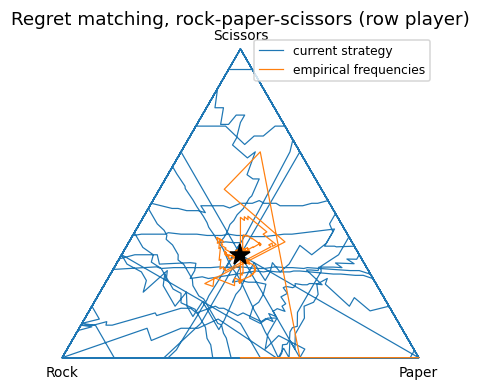

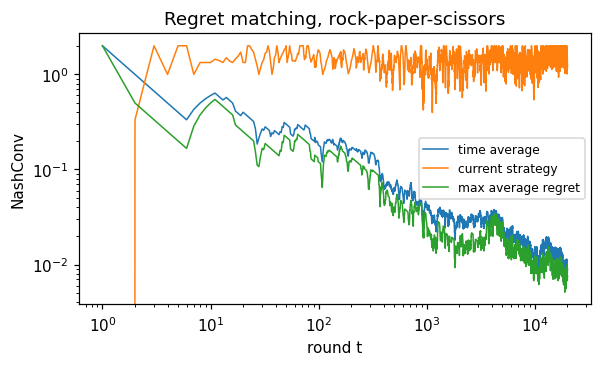

In [14]:
A, B = GAMES["rock_paper_scissors"]
h = regret_matching(A, B, T=20_000)
eq = np.ones(3) / 3

plot_simplex({"current strategy": h["x"][:3000], "empirical frequencies": h["x_avg"]}, eq=eq,
             corners=("Rock", "Paper", "Scissors"),
             title="Regret matching, rock-paper-scissors (row player)")
plot_nash_conv({"time average": nash_conv_path(A, B, h["x_avg"], h["y_avg"]),
                "current strategy": nash_conv_path(A, B, h["x"], h["y"]),
                "max average regret": h["avg_regret"]},
               title="Regret matching, rock-paper-scissors")

The pattern is the same as for fictitious play in matching pennies. The current strategy keeps swinging around the simplex (only its first 3,000 rounds are drawn, to keep the plot readable), while the empirical frequencies settle at the centre. The average regret and the NashConv of the averages decrease together, at roughly the $1/\sqrt{t}$ rate that the theory guarantees for regret.

### Shapley's game again: no regret, but no Nash either

In [15]:
A, B = GAMES["shapley"]
h = regret_matching(A, B, T=20_000)
print(f"max average regret after 20,000 rounds: {h['avg_regret'][-1]:.4f}")
print(f"NashConv of the empirical frequencies:  {nash_conv(A, B, h['x_avg'][-1], h['y_avg'][-1]):.4f}")

max average regret after 20,000 rounds: 0.0004
NashConv of the empirical frequencies:  0.2864


This is the most instructive output in the section. Both players have essentially no regret: neither could have done better by committing to any single action in hindsight. And yet their marginal frequencies are far from the equilibrium. There is no contradiction. No regret describes the *joint* distribution of play, which can be correlated through the history (after one outcome, a particular outcome tends to follow). Such a joint distribution can be a coarse correlated equilibrium without its marginals forming a Nash equilibrium.

In [16]:
# sanity checks
A, B = GAMES["rock_paper_scissors"]
h = regret_matching(A, B, T=20_000)
assert nash_conv(A, B, h["x_avg"][-1], h["y_avg"][-1]) < 0.05
assert h["avg_regret"][-1] < 0.02

A, B = GAMES["shapley"]
h = regret_matching(A, B, T=20_000)
assert h["avg_regret"][-1] < 0.02                                   # no regret ...
assert nash_conv(A, B, h["x_avg"][-1], h["y_avg"][-1]) > 0.1        # ... yet not Nash
print("✓ regret_matching")

✓ regret_matching


> **Going further.** (1) Implement the *conditional* version of Hart & Mas-Colell (2000) and check that the empirical joint distribution approaches the correlated-equilibrium polytope; the LP of §4.6 lets you test membership. (2) Regret matching$^+$ (Tammelin, 2014) resets negative regrets to zero after every round. Compare how fast its averages converge in rock-paper-scissors.

## 5 · Q-learning

Both rules so far used the payoff matrix: fictitious play to compute best responses, regret matching to evaluate actions that were not played. A reinforcement learner is not given the matrix. It sees only the reward of the action it actually took.

In a repeated matrix game there is no state to keep track of, so Q-learning (Watkins & Dayan, 1992) reduces to keeping one estimate $Q(i)$ per action and nudging it towards each observed reward:

$$Q(i_t) \;\leftarrow\; Q(i_t) + \alpha\,\big(r_t - Q(i_t)\big),$$

where $\alpha$ is the learning rate. To keep exploring, the action is drawn from a softmax (Boltzmann) distribution over the estimates:

$$x_t(i) \;=\; \frac{\exp\big(Q(i)/\tau\big)}{\sum_k \exp\big(Q(k)/\tau\big)} .$$

The temperature $\tau$ sets the balance. A high temperature makes play nearly uniform; a low one makes it nearly greedy.

The softmax alone has a trap. All estimates start at zero, and only the action that is played gets updated. If one action happens to earn a good reward early, its estimate rises, the others are almost never sampled again, and their estimates are never corrected. We therefore mix in a small amount of uniform exploration: with probability $\varepsilon$ the learner picks an action uniformly at random. The effect of this choice is shown below.

When each player runs its own Q-learner and treats the other as part of the environment, we have **independent learners** (Claus & Boutilier, 1998). This breaks the assumption that makes single-agent Q-learning work, namely that the environment is stationary. From each player's point of view, the rewards of an action drift as the opponent learns.

One more consequence of the softmax is worth stating in advance. With a fixed temperature a learner never plays a best response exactly, so its rest points are not Nash equilibria but **logit quantal response equilibria** (McKelvey & Palfrey, 1995), which approach Nash as $\tau \to 0$. Kianercy & Galstyan (2012) work out this correspondence for Boltzmann Q-learning in 2×2 games.

In [17]:
def softmax(q, tau):
    '''Boltzmann distribution over the values q at temperature tau.'''
    z = (q - q.max()) / tau          # subtracting the max avoids overflow
    e = np.exp(z)
    return e / e.sum()


def q_learning(A, B, T, alpha=0.05, tau=0.1, epsilon=0.02, seed=0):
    '''Two independent stateless Q-learners with Boltzmann exploration.

    Parameters
    ----------
    A, B : np.ndarray, shape (m, n)
        Payoff matrices of the row and the column player. Each learner only
        ever sees its own realised reward, never the matrices.
    T : int
        Number of rounds.
    alpha : float
        Learning rate.
    tau : float
        Softmax temperature.
    epsilon : float
        Probability of choosing uniformly at random instead of from the softmax.
    seed : int
        Seed of the random generator used to sample actions.

    Returns
    -------
    dict with arrays of length T:
        "x", "y"          : softmax policies used in each round
        "x_avg", "y_avg"  : empirical frequencies of the sampled actions
    '''
    rng = np.random.default_rng(seed)
    m, n = A.shape
    Q_x, Q_y = np.zeros(m), np.zeros(n)
    count_x, count_y = np.zeros(m), np.zeros(n)
    hist = {k: [] for k in ["x", "y", "x_avg", "y_avg"]}
    for t in range(1, T + 1):
        x = (1 - epsilon) * softmax(Q_x, tau) + epsilon / m
        y = (1 - epsilon) * softmax(Q_y, tau) + epsilon / n
        i = rng.choice(m, p=x)
        j = rng.choice(n, p=y)
        Q_x[i] += alpha * (A[i, j] - Q_x[i])       # only the played action is updated
        Q_y[j] += alpha * (B[i, j] - Q_y[j])
        count_x[i] += 1
        count_y[j] += 1
        hist["x"].append(x);  hist["x_avg"].append(count_x / t)
        hist["y"].append(y);  hist["y_avg"].append(count_y / t)
    return {k: np.array(v) for k, v in hist.items()}

### Three games, three behaviours

The plots show the first 1,500 rounds of each run.

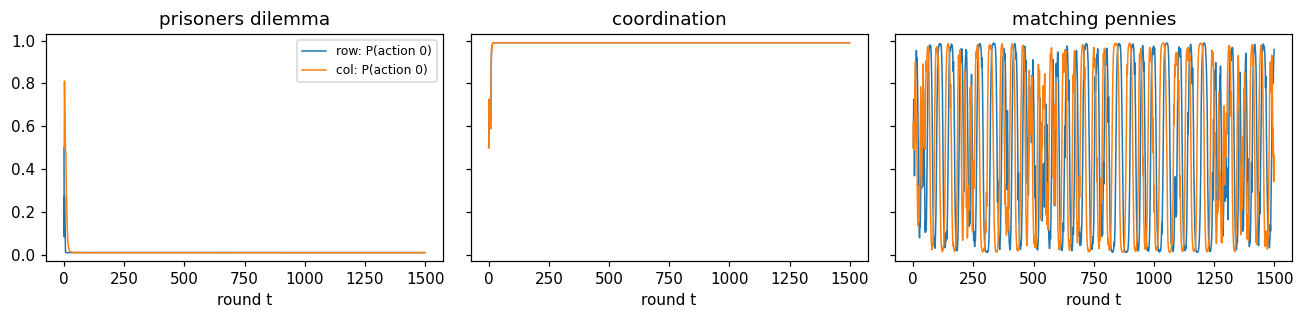

In [18]:
runs = {}
for name in ["prisoners_dilemma", "coordination", "matching_pennies"]:
    A, B = GAMES[name]
    runs[name] = q_learning(A, B, T=5_000)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (name, h) in zip(axes, runs.items()):
    ax.plot(h["x"][:1500, 0], lw=1, label="row: P(action 0)")
    ax.plot(h["y"][:1500, 0], lw=1, label="col: P(action 0)")
    ax.set(title=name.replace("_", " "), xlabel="round t", ylim=(-0.03, 1.03))
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

- **Prisoner's dilemma.** Both learners drift to Defect (probability of action 0 goes to nearly zero; the $\varepsilon$ floor keeps it slightly positive). Defect earns more whatever the other does, so the estimates sort themselves out regardless of the opponent's drift. Dominance is easy to learn, as long as every action keeps being tried.
- **Coordination.** The learners lock into one of the two pure equilibria. Which one depends on early luck; with other seeds they sometimes settle on the worse one, (Right, Right), which pays 1 instead of 2. Nothing in independent learning steers them to the better equilibrium.
- **Matching pennies.** The policies never settle. Each learner chases the other: when the row player leans towards Heads, the column player's Tails estimate rises, which pushes the row player to Tails, and so on. This is the multi-agent non-stationarity described above, in its simplest form.

### Why the exploration floor matters

The claim "as long as every action keeps being tried" deserves a test. Here are 20 runs of the prisoner's dilemma with and without the $\varepsilon$ floor.

In [19]:
A, B = GAMES["prisoners_dilemma"]
for eps in [0.0, 0.02]:
    stuck = 0
    for seed in range(20):
        h = q_learning(A, B, T=5_000, epsilon=eps, seed=seed)
        stuck += h["x"][-1][0] > 0.5 or h["y"][-1][0] > 0.5
    print(f"epsilon = {eps:.2f}:  {stuck:2d} of 20 runs end with a player still cooperating")

epsilon = 0.00:   4 of 20 runs end with a player still cooperating


epsilon = 0.02:   0 of 20 runs end with a player still cooperating


Without the floor, some runs get stuck on Cooperate. The mechanism is the one described above: when both players start by cooperating, Cooperate earns 3, its estimate climbs, and at temperature 0.1 the probability of ever trying Defect becomes astronomically small. The learner never discovers that Defect would earn 5. This is not a flaw of game theory; it is the exploration–exploitation problem of reinforcement learning, made worse by an opponent whose behaviour shifts under the learner's feet.

Back to coordination: which of the two equilibria do the learners find?

In [20]:
A, B = GAMES["coordination"]
outcomes = []
for seed in range(20):
    h = q_learning(A, B, T=3_000, seed=seed)
    outcomes.append("(Left, Left)" if h["x"][-1][0] > 0.5 else "(Right, Right)")
print(pd.Series(outcomes).value_counts().to_string())

(Left, Left)      12
(Right, Right)     8


In [21]:
# sanity checks
A, B = GAMES["prisoners_dilemma"]
h = q_learning(A, B, T=5_000)
assert h["x"][-1][1] > 0.95 and h["y"][-1][1] > 0.95                # both defect (up to epsilon)

A, B = GAMES["coordination"]
h = q_learning(A, B, T=5_000)
assert nash_conv(A, B, h["x"][-1], h["y"][-1]) < 0.1                # settles near a pure equilibrium

A, B = GAMES["matching_pennies"]
h = q_learning(A, B, T=5_000)
assert np.mean(nash_conv_path(A, B, h["x"][-1000:], h["y"][-1000:])) > 0.3   # keeps cycling
print("✓ q_learning")

✓ q_learning


> **Going further.** WoLF-PHC (Bowling & Veloso, 2002) keeps the Q-learning update but changes the policy with a variable step: slowly when winning, fast when losing. That single change makes the current policy converge in games like matching pennies. It is a natural next learner for the puzzle game.

## 6 · Side by side

We now run the three learners on every game and report NashConv both for the time average and for the current strategy at the end. Fictitious play is deterministic; for the two stochastic learners we average over a few seeds.

In [22]:
def run_all(T=10_000, seeds=range(5)):
    '''NashConv at round T of the average and the current strategy, for every game and learner.

    Returns
    -------
    pd.DataFrame indexed by game, with a (learner, measure) column MultiIndex.
    '''
    learners = {
        "fictitious play": lambda A, B, s: fictitious_play(A, B, T),
        "regret matching": lambda A, B, s: regret_matching(A, B, T, seed=s),
        "Q-learning":      lambda A, B, s: q_learning(A, B, T, seed=s),
    }
    rows = {}
    for name, (A, B) in GAMES.items():
        row = {}
        for lname, run in learners.items():
            reps = [0] if lname == "fictitious play" else list(seeds)
            avg, cur = [], []
            for s in reps:
                h = run(A, B, s)
                avg.append(nash_conv(A, B, h["x_avg"][-1], h["y_avg"][-1]))
                cur.append(nash_conv(A, B, h["x"][-1], h["y"][-1]))
            row[(lname, "average")] = np.mean(avg)
            row[(lname, "current")] = np.mean(cur)
        rows[name] = row
    return pd.DataFrame(rows).T.round(3)


table = run_all()
table

fictitious play         regret matching          \
                            average current         average current   
prisoners_dilemma             0.000     0.0           0.000   0.000   
matching_pennies              0.014     2.0           0.014   1.575   
rock_paper_scissors           0.013     2.0           0.023   1.434   
battle_of_the_sexes           0.000     0.0           0.000   0.000   
coordination                  0.000     0.0           0.001   0.000   
dominance_solvable            0.000     0.0           0.003   0.000   
shapley                       0.288     1.0           0.284   1.000   

                    Q-learning          
                       average current  
prisoners_dilemma        0.084   0.020  
matching_pennies         0.003   1.463  
rock_paper_scissors      0.035   1.053  
battle_of_the_sexes      0.029   0.029  
coordination             0.032   0.031  
dominance_solvable       0.524   0.039  
shapley                  0.008   0.635

How to read the table. A value close to zero means the corresponding object is close to a Nash equilibrium after 10,000 rounds. Small positive values for Q-learning (around 0.02–0.04) are the price of the $\varepsilon$ floor: a learner that keeps exploring is never exactly at equilibrium.

- In the **prisoner's dilemma** and the **dominance-solvable** game every learner ends up playing the equilibrium. Iterated dominance is the easy case for learning, just as it was for computation. Q-learning's *average* in the dominance-solvable game is still high because the average includes the long exploratory start; the current strategy is already there.
- In the **zero-sum** games (matching pennies, rock-paper-scissors) all three averages approach the equilibrium, but none of the current strategies do. The players keep cycling.
- In **coordination** and **battle of the sexes** the learners settle on a pure equilibrium, so both measures are small.
- **Shapley's game** defeats fictitious play and regret matching on both measures, even though regret matching's regret vanishes. Q-learning's average, on the other hand, comes out close to the equilibrium. A plausible explanation is the smoothing from softmax exploration, which acts like the smooth fictitious play mentioned in section 3, but a few seeds on one game are not evidence. Checking this systematically (varying $\tau$, $\alpha$ and the horizon) would be a good small experiment.

The difference between the two columns is what "converges" hides. A statement like "regret matching converges to Nash in zero-sum games" is true of the averages and false of the strategies that are actually being played.

## 7 · Discussion

**Is averaging a trick?** Partly. The average is not something either player ever plays. In the puzzle game it corresponds to an observer who has watched many rounds, not to a player who can be trusted to act well today. When the goal is to *compute* an equilibrium, as in poker solvers, averages are perfectly fine and regret-based methods are the standard tool. When the goal is to *predict behaviour*, the current strategy is what matters, and cycling is a real phenomenon, not an artefact.

**Can the current strategy converge?** In zero-sum games, yes, with modified dynamics. Optimistic variants of no-regret learning, which add a correction based on the last gradient, have last-iterate convergence in bilinear zero-sum games (Daskalakis, Ilyas, Syrgkanis & Zeng, 2018). For general games there is no dynamic that is both simple and guaranteed to converge to Nash; Hart & Mas-Colell (2003) show this for a broad class of "uncoupled" dynamics, in which each player's rule depends only on her own payoffs.

**How do these rules relate to evolution?** Shoham & Leyton-Brown §7.7.1 describes the replicator dynamic, in which the share of a strategy in a population grows in proportion to how much better than average it does (Taylor & Jonker, 1978). It is the continuous-time limit of several reinforcement-learning rules (Börgers & Sarin, 1997), and Boltzmann Q-learning follows the replicator dynamic plus an exploration term (Tuyls, Verbeeck & Lenaerts, 2003). The cycling seen in rock-paper-scissors is the discrete-time shadow of closed orbits of the replicator dynamic.

**What this means for the project.** For the "ghost agent" feature of the puzzles, each world suggests a learner:

- World 1 (dominance): any of the three, since they all find the answer and the path is short and easy to follow.
- World 2 (mixed equilibria): regret matching, showing both the swinging current strategy and the settling average. The contrast is the lesson of the level.
- Coordination levels: independent Q-learners over several seeds, to show that *which* equilibrium is reached depends on luck.

A natural difficulty measure for the puzzle generator is the number of rounds regret matching needs before the average's NashConv drops below a threshold.

---
## References

**Textbooks**

- Fudenberg, D., & Levine, D. K. (1998). *The Theory of Learning in Games*. MIT Press.
- Shoham, Y., & Leyton-Brown, K. (2009). *Multiagent Systems: Algorithmic, Game-Theoretic, and Logical Foundations*. Cambridge University Press.

**Fictitious play**

- Brown, G. W. (1951). Iterative solution of games by fictitious play. In T. C. Koopmans (Ed.), *Activity Analysis of Production and Allocation* (pp. 374–376). Wiley.
- Robinson, J. (1951). An iterative method of solving a game. *Annals of Mathematics*, 54(2), 296–301.
- Miyasawa, K. (1961). On the convergence of the learning process in a 2×2 non-zero-sum two-person game. Research Memorandum No. 33, Econometric Research Program, Princeton University.
- Shapley, L. S. (1964). Some topics in two-person games. In M. Dresher, L. S. Shapley, & A. W. Tucker (Eds.), *Advances in Game Theory* (pp. 1–28). Princeton University Press.
- Karlin, S. (1959). *Mathematical Methods and Theory in Games, Programming, and Economics*. Addison-Wesley.
- Fudenberg, D., & Kreps, D. M. (1993). Learning mixed equilibria. *Games and Economic Behavior*, 5(3), 320–367.
- Monderer, D., & Shapley, L. S. (1996). Fictitious play property for games with identical interests. *Journal of Economic Theory*, 68(1), 258–265.
- Daskalakis, C., & Pan, Q. (2014). A counter-example to Karlin's strong conjecture for fictitious play. *Proceedings of the 55th IEEE Symposium on Foundations of Computer Science (FOCS)*, 11–20.

**Regret**

- Hannan, J. (1957). Approximation to Bayes risk in repeated play. In M. Dresher, A. W. Tucker, & P. Wolfe (Eds.), *Contributions to the Theory of Games* (Vol. 3, pp. 97–139). Princeton University Press.
- Hart, S., & Mas-Colell, A. (2000). A simple adaptive procedure leading to correlated equilibrium. *Econometrica*, 68(5), 1127–1150.
- Hart, S., & Mas-Colell, A. (2003). Uncoupled dynamics do not lead to Nash equilibrium. *American Economic Review*, 93(5), 1830–1836.
- Zinkevich, M., Johanson, M., Bowling, M., & Piccione, C. (2007). Regret minimization in games with incomplete information. *Advances in Neural Information Processing Systems*, 20.
- Tammelin, O. (2014). Solving large imperfect information games using CFR+. arXiv:1407.5042.
- Daskalakis, C., Ilyas, A., Syrgkanis, V., & Zeng, H. (2018). Training GANs with optimism. *International Conference on Learning Representations (ICLR)*.

**Reinforcement learning and multi-agent learning**

- Watkins, C. J. C. H., & Dayan, P. (1992). Q-learning. *Machine Learning*, 8(3–4), 279–292.
- Claus, C., & Boutilier, C. (1998). The dynamics of reinforcement learning in cooperative multiagent systems. *Proceedings of the 15th National Conference on Artificial Intelligence (AAAI)*, 746–752.
- Bowling, M., & Veloso, M. (2002). Multiagent learning using a variable learning rate. *Artificial Intelligence*, 136(2), 215–250.
- McKelvey, R. D., & Palfrey, T. R. (1995). Quantal response equilibria for normal form games. *Games and Economic Behavior*, 10(1), 6–38.
- Kianercy, A., & Galstyan, A. (2012). Dynamics of Boltzmann Q learning in two-player two-action games. *Physical Review E*, 85(4), 041145.
- Lanctot, M., Zambaldi, V., Gruslys, A., Lazaridou, A., Tuyls, K., Pérolat, J., Silver, D., & Graepel, T. (2017). A unified game-theoretic approach to multiagent reinforcement learning. *Advances in Neural Information Processing Systems*, 30.

**Evolutionary dynamics**

- Taylor, P. D., & Jonker, L. B. (1978). Evolutionarily stable strategies and game dynamics. *Mathematical Biosciences*, 40(1–2), 145–156.
- Börgers, T., & Sarin, R. (1997). Learning through reinforcement and replicator dynamics. *Journal of Economic Theory*, 77(1), 1–14.
- Tuyls, K., Verbeeck, K., & Lenaerts, T. (2003). A selection-mutation model for Q-learning in multi-agent systems. *Proceedings of the 2nd International Joint Conference on Autonomous Agents and Multiagent Systems (AAMAS)*, 693–700.

---
### Where these functions go next

The three learners and `nash_conv` become `engine/learners.py`, with the checks in `tests/test_learners.py`. The next step of the project is the level format and the puzzle generator, where `nash_conv` and regret matching also serve as a difficulty measure.